<a href="https://colab.research.google.com/github/omaryasser1907/FOOD-1O1-classification/blob/main/FOOD_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CUSTOM DATASET



In [1]:
import torch
from torch import nn
device="cuda" if torch.cuda.is_available () else "cpu"
device


'cuda'

In [2]:
from pathlib import Path
import requests
import zipfile
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} is here ,skip downloading " )
else:
  print(f"{image_path} is not here , so start downloading")
  image_path.mkdir(parents=True,exist_ok=True)

with open(data_path/"pizza_steak_sushi.zip","wb")as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  f.write(request.content)
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r")as zip_ref:
  print(f"unzipping zip file ")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi is not here , so start downloading
unzipping zip file 


In [3]:
# walking through the data
import os
def walk_through_data (dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} :directories and {len(filenames)}: images in {dirpath} folder")

In [4]:
walk_through_data(image_path)

there are 2 :directories and 0: images in data/pizza_steak_sushi folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/train folder
there are 0 :directories and 75: images in data/pizza_steak_sushi/train/steak folder
there are 0 :directories and 72: images in data/pizza_steak_sushi/train/sushi folder
there are 0 :directories and 78: images in data/pizza_steak_sushi/train/pizza folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/test folder
there are 0 :directories and 19: images in data/pizza_steak_sushi/test/steak folder
there are 0 :directories and 31: images in data/pizza_steak_sushi/test/sushi folder
there are 0 :directories and 25: images in data/pizza_steak_sushi/test/pizza folder


In [5]:
# setting train & test directories
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [6]:
# visualizing images
import random
from PIL import Image
random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))
random_image=random.choice(image_path_list)
image_class=random_image.parent.stem
img=Image.open(random_image)
# printing all metadata
print(f"random image choice : {random_image}")
print(f"random image class : {image_class}")
print(f"random image height : {img.height}")
print(f"random image width : {img.width}")
#img

random image choice : data/pizza_steak_sushi/train/steak/2614649.jpg
random image class : steak
random image height : 512
random image width : 384


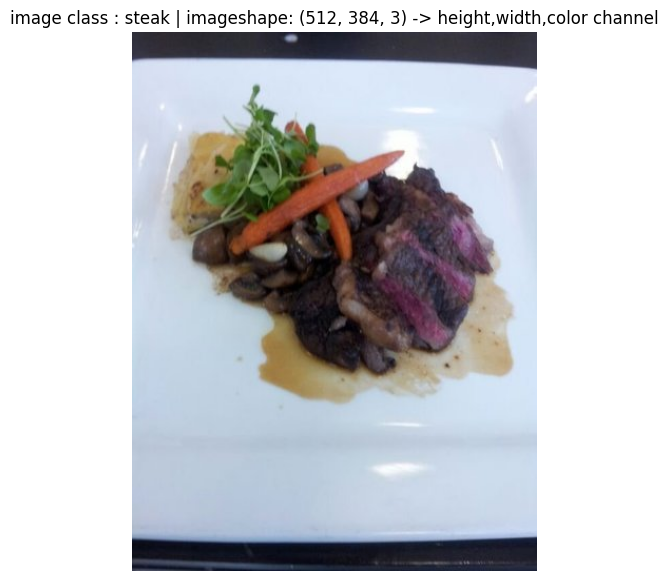

In [7]:
# matplot visualizing
import numpy as np
import matplotlib.pyplot as plt
img_as_array=np.asarray(img)
# plotting
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} | imageshape: {img_as_array.shape} -> height,width,color channel")
plt.axis(False) ;

In [8]:
!pip install torchvision

In [9]:
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
data_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [10]:
data_transforms(img).shape

torch.Size([3, 64, 64])

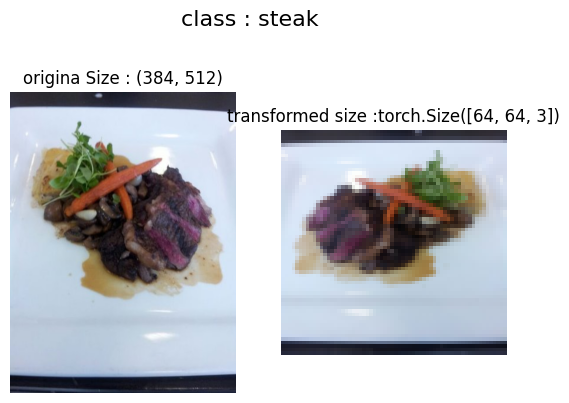

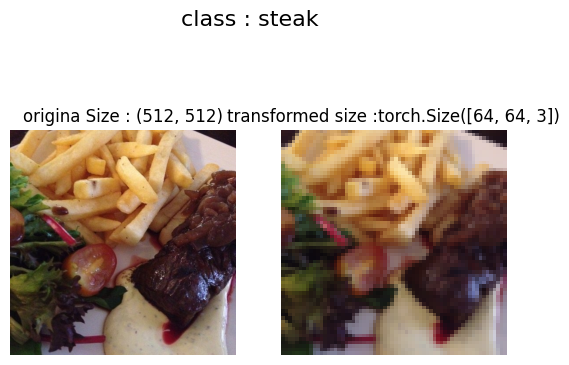

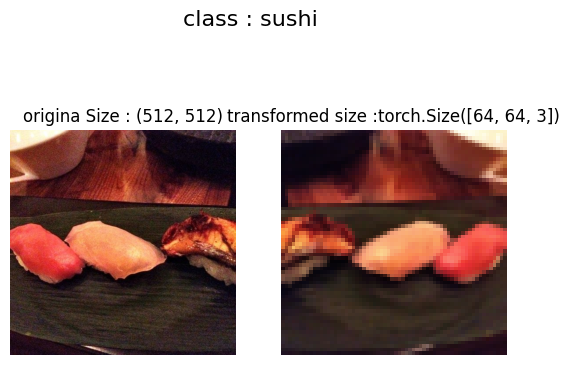

In [11]:
# plotting original vs transformed images
def plot_transformed_image (image_paths:list,
                            transform,
                            n=3,
                            seed=None):
  if seed :
    random.seed(seed)
  random_image_paths=random.sample(image_path_list,k=n)
  for image_path in (random_image_paths):
    with Image.open(image_path)as f :
      fig,ax=plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"origina Size : {f.size}")
      ax[0].axis(False)
      transformed_image=transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed size :{transformed_image.shape}")
      ax[1].axis(False)
      fig.suptitle(f"class : {image_path.parent.stem}",fontsize=16 )
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transforms,
                       n=3,
                       seed=42)



In [12]:
## loading data using ImageFolder
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transforms,
                                target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                                transform=data_transforms,
                                target_transform=None)


In [13]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [14]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [15]:
# creating classes dictionary
classes_dict=train_data.class_to_idx
classes_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [16]:
len(train_data),len(test_data)

(225, 75)

In [17]:
# indexing one image and label to work on
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor :\n {img}")
print(f"image shape : {img.shape }")
print(f"image type : {img.dtype}")
print(f"image label : {label}")
print(f"label data type : {type(label)}")


image tensor :
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.

 original img shape : torch.Size([3, 64, 64])
 permuted img shape : torch.Size([64, 64, 3])


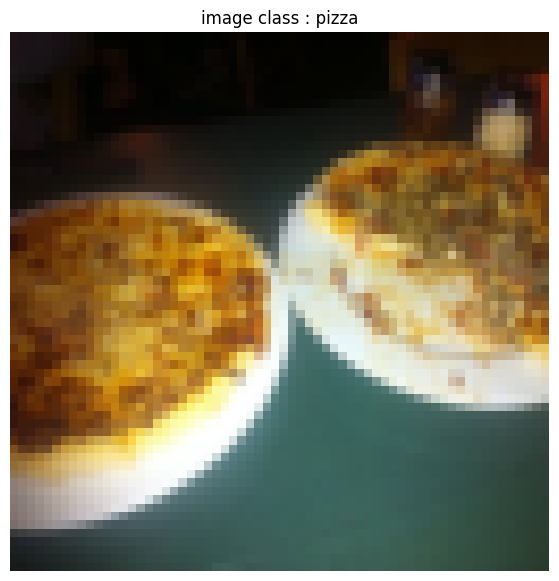

In [18]:
# plotting the selected image
img_permute=img.permute(1,2,0)

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(f"image class : {class_names[label]}")
# printing original shape vs permuted shape
print(f" original img shape : {img.shape}")
print(f" permuted img shape : {img_permute.shape}")

## let's create DATALOADER


In [19]:
from torch.utils.data import DataLoader
BATCHSIZE=32
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCHSIZE,
                            num_workers=1,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test_data ,
                           batch_size=BATCHSIZE,
                           num_workers=1,
                           shuffle=None)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e36adc39160>,
 <torch.utils.data.dataloader.DataLoader at 0x7e368d7e5450>)

In [20]:
len(train_dataloader),len(test_dataloader)

(8, 3)

In [21]:
len(train_data),len(test_data)

(225, 75)

In [22]:
## adding batch size dim on our img
img,label=next(iter(train_dataloader))
print(f"image shape : {img.shape} -> [batch_size,color_channel,height,width]")
print(f"label shape : {label.shape}")

image shape : torch.Size([32, 3, 64, 64]) -> [batch_size,color_channel,height,width]
label shape : torch.Size([32])


In [23]:
# augentations using TrivialAugmenWide
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [24]:
image_path

PosixPath('data/pizza_steak_sushi')

In [25]:
image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/steak/1961025.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/176508.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/560503.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1966300.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/97656.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3577618.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/922752.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/461689.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/167069.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1787505.jpg')]

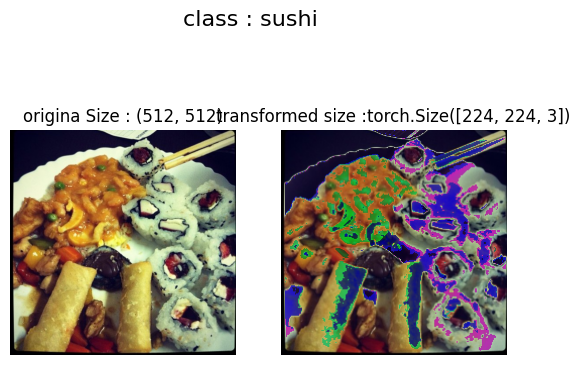

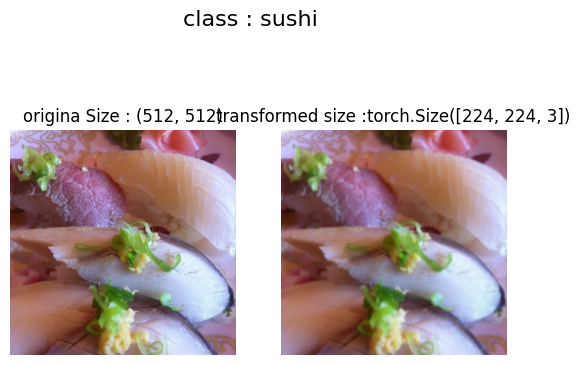

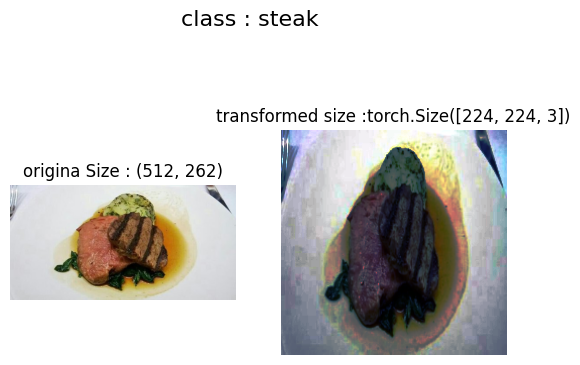

In [26]:
# let's plot
plot_transformed_image(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None)

## model using TINY VGG

In [27]:
## CREATING AND LOADING DATA FOR FIRST MODEL
from torchvision import transforms
simple_transform= transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()

])

In [28]:
from torchvision import datasets
train_data_model0=datasets.ImageFolder(
    root=train_dir,
    transform=simple_transform,
    target_transform=None
)
test_data_model0= datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform,
    target_transform=None
)



In [29]:
# datsets to dataloader
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader_model0=DataLoader(
    dataset=train_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count()
)
test_dataloader_model0=DataLoader(
    dataset=test_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count()
)


In [30]:
len(train_dataloader_model0),len(test_dataloader_model0)

(8, 3)

In [31]:
class TinyVGG (nn.Module):
  def __init__ (self,input_shape:int,
                    output_shape:int,
                    hidden_units:int) -> None:
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=0,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
        )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=0,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
        )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward (self,x) :
    x=self.conv_block_1(x)
    print(x.shape)
    x=self.conv_block_2(x)
    print(x.shape)
    x=self.classifier(x)
    print(x.shape)
    return x



In [32]:
# creating an instance
torch.manual_seed(42)
model_0=TinyVGG(input_shape=3, # num of color channels
                output_shape=len(class_names),
                hidden_units=10).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [33]:
# passing a batch of the data to the model
image_batch,label_batch=next(iter(train_dataloader_model0))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [34]:
model_0(image_batch.to(device))

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
torch.Size([32, 3])


tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2317e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [35]:
# torchinfo to get model summary
! pip install torchinfo

In [36]:
from torchinfo import summary
summary(model_0,[1,3,64,64])

torch.Size([1, 10, 30, 30])
torch.Size([1, 10, 13, 13])
torch.Size([1, 3])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## train & test functions

In [39]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device=device):
  model.train()
  train_loss,train_acc=0,0
  for batch,(x,y) in enumerate (dataloader):
    x,y=x.to(device),y.to(device)
    y_pred=model(x)
    train_loss+=loss_fn(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class=torch.argmax(torch.softmax(y_pred),dim=1)
    train_acc=+(y_pred_class==y).sum().item()/len(y_pred)
  # average per batch
  train_loss/=len(dataloader)
  train_acc/=len(dataloader)


In [40]:
def test_step (model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device=device):
  model.eval()
  with torch.inference_mode():
    test_loss,test_acc=0,0
    for batch,(x,y) in enumerate(dataloader):
      x,y=x.to(device),y.to(device)
      test_pred=model(x)
      test_loss+=loss_fn(test_pred,y)
      test_pred_label=torch.argmax(torch.softmax(test_pred,dim=1),dim=1)
      test_acc+=(test_pred_label==y).sum().item()/len(test_pred_label)
    test_loss/=len(dataloader)
    test_acc/=len(dataloader)
  return test_loss,test_acc
